In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/dhriti1015/yolov11-final/other/default/1/best_v5_yolo11.pt
/kaggle/input/datasets/dhriti1015/dataset272images/dataset - Copy - Copy/dataset - Copy - Copy/labels/ch2_ohr_ncp_20210402T0155096873_b_brw_d18_110.txt
/kaggle/input/datasets/dhriti1015/dataset272images/dataset - Copy - Copy/dataset - Copy - Copy/labels/ch2_ohr_ncp_20210331T2033243734_b_brw_d18_240.txt
/kaggle/input/datasets/dhriti1015/dataset272images/dataset - Copy - Copy/dataset - Copy - Copy/labels/ch2_ohr_ncp_20210401T2357376656_b_brw_d18_434.txt
/kaggle/input/datasets/dhriti1015/dataset272images/dataset - Copy - Copy/dataset - Copy - Copy/labels/ch2_ohr_ncp_20210401T2357376656_b_brw_d18_456.txt
/kaggle/input/datasets/dhriti1015/dataset272images/dataset - Copy - Copy/dataset - Copy - Copy/labels/ch2_ohr_ncp_20210331T2033243734_b_brw_d18_278.txt
/kaggle/input/datasets/dhriti1015/dataset272images/dataset - Copy - Copy/dataset - Copy - Copy/labels/ch2_ohr_ncp_20210402T0155096873_b_brw_d18_103.txt
/kaggle/

In [2]:
import os
import shutil

# 🔧 INPUT: Kaggle dataset paths
datasets = [
    "/kaggle/input/datasets/dhriti1015/dataset272images/autodataset/auto_dataset_next_100_labeled",
    "/kaggle/input/datasets/dhriti1015/dataset272images/dataset - Copy - Copy/dataset - Copy - Copy",
    "/kaggle/input/datasets/dhriti1015/dataset272images/new_dataset_2 (2)/new_dataset_2",
    "/kaggle/input/datasets/dhriti1015/dataset272images/next_20_labelled/new_dataset_1 - Copy"
]

# 🔧 OUTPUT
output = "/kaggle/working/final_dataset"

img_out = os.path.join(output, "images")
lbl_out = os.path.join(output, "labels")

os.makedirs(img_out, exist_ok=True)
os.makedirs(lbl_out, exist_ok=True)

counter = 0

for dataset in datasets:
    img_dir = os.path.join(dataset, "images")
    lbl_dir = os.path.join(dataset, "labels")

    # Skip if structure is wrong
    if not os.path.exists(img_dir) or not os.path.exists(lbl_dir):
        print(f"⚠️ Skipping {dataset} (missing images/labels folder)")
        continue

    for file in os.listdir(img_dir):
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            
            img_path = os.path.join(img_dir, file)
            lbl_path = os.path.join(lbl_dir, file.rsplit('.', 1)[0] + '.txt')

            if os.path.exists(lbl_path):
                new_name = f"img_{counter:06d}"

                shutil.copy(img_path, os.path.join(img_out, new_name + os.path.splitext(file)[1]))
                shutil.copy(lbl_path, os.path.join(lbl_out, new_name + ".txt"))

                counter += 1

print(f"✅ Done! Total merged files: {counter}")

✅ Done! Total merged files: 262


In [3]:
import os

datasets = [
    "/kaggle/input/datasets/dhriti1015/dataset272images/autodataset/auto_dataset_next_100_labeled",
    "/kaggle/input/datasets/dhriti1015/dataset272images/dataset - Copy - Copy/dataset - Copy - Copy",
    "/kaggle/input/datasets/dhriti1015/dataset272images/new_dataset_2 (2)/new_dataset_2",
    "/kaggle/input/datasets/dhriti1015/dataset272images/next_20_labelled/new_dataset_1 - Copy"
]


for dataset in datasets:
    print(f"\n📁 Dataset: {dataset}")
    
    img_dir = os.path.join(dataset, "images")
    lbl_dir = os.path.join(dataset, "labels")
    
    # Count images
    if os.path.exists(img_dir):
        img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"Images: {len(img_files)}")
    else:
        print("Images folder not found ❌")
    
    # Count labels
    if os.path.exists(lbl_dir):
        lbl_files = [f for f in os.listdir(lbl_dir) if f.endswith('.txt')]
        print(f"Labels: {len(lbl_files)}")
    else:
        print("Labels folder not found ❌")


📁 Dataset: /kaggle/input/datasets/dhriti1015/dataset272images/autodataset/auto_dataset_next_100_labeled
Images: 122
Labels: 123

📁 Dataset: /kaggle/input/datasets/dhriti1015/dataset272images/dataset - Copy - Copy/dataset - Copy - Copy
Images: 100
Labels: 101

📁 Dataset: /kaggle/input/datasets/dhriti1015/dataset272images/new_dataset_2 (2)/new_dataset_2
Images: 20
Labels: 21

📁 Dataset: /kaggle/input/datasets/dhriti1015/dataset272images/next_20_labelled/new_dataset_1 - Copy
Images: 20
Labels: 21


In [4]:
def stratified_split(labels_dir, images_dir, output_dir, val_ratio=0.15, test_ratio=0.15):
    from pathlib import Path
    import shutil, random

    labels_dir = Path(labels_dir)
    images_dir = Path(images_dir)

    large, medium, small_only = [], [], []

    for txt in labels_dir.glob("*.txt"):
        classes_in_image = set()
        with open(txt) as f:
            for line in f:
                cls = int(line.split()[0])
                classes_in_image.add(cls)
        if 2 in classes_in_image:
            large.append(txt.stem)
        elif 1 in classes_in_image:
            medium.append(txt.stem)
        else:
            small_only.append(txt.stem)

    def split_group(group):
        random.shuffle(group)
        n = len(group)
        n_test = max(1, int(n * test_ratio))
        n_val  = max(1, int(n * val_ratio))
        return group[n_test+n_val:], group[n_val:n_val+n_test], group[:n_val]

    train_ids, test_ids, val_ids = [], [], []
    for group in [large, medium, small_only]:
        tr, te, va = split_group(group)
        train_ids.extend(tr)
        test_ids.extend(te)
        val_ids.extend(va)

    for split_name, ids in [("train", train_ids), ("val", val_ids), ("test", test_ids)]:
        img_out = Path(output_dir) / "images" / split_name
        lbl_out = Path(output_dir) / "labels" / split_name
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)
        for stem in ids:
            for ext in [".jpg", ".png"]:
                src = images_dir / (stem + ext)
                if src.exists():
                    shutil.copy(src, img_out / src.name)
            shutil.copy(labels_dir / (stem + ".txt"), lbl_out / (stem + ".txt"))

    print(f"Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")
    print(f"Large  — train: {sum(1 for i in train_ids if i in large)}, val: {sum(1 for i in val_ids if i in large)}, test: {sum(1 for i in test_ids if i in large)}")
    print(f"Medium — train: {sum(1 for i in train_ids if i in medium)}, val: {sum(1 for i in val_ids if i in medium)}, test: {sum(1 for i in test_ids if i in medium)}")
    print(f"Small  — train: {sum(1 for i in train_ids if i in small_only)}, val: {sum(1 for i in val_ids if i in small_only)}, test: {sum(1 for i in test_ids if i in small_only)}")

stratified_split(
    labels_dir="/kaggle/working/final_dataset/labels",
    images_dir="/kaggle/working/final_dataset/images",
    output_dir="/kaggle/working/dataset_v3"
)

Train: 188 | Val: 37 | Test: 37
Large  — train: 95, val: 19, test: 19
Medium — train: 40, val: 8, test: 8
Small  — train: 53, val: 10, test: 10


In [5]:
data_yaml = """path: /kaggle/working/dataset_v3
train: images/train
val: images/val
test: images/test

nc: 3
names: ["crater_small", "crater_medium", "crater_large"]
"""

with open("/kaggle/working/dataset_v3/data.yaml", "w") as f:
    f.write(data_yaml)

print("✅ data.yaml created!")

✅ data.yaml created!


In [6]:
with open("/kaggle/working/dataset_v3/data.yaml", "r") as f:
    print(f.read())

path: /kaggle/working/dataset_v3
train: images/train
val: images/val
test: images/test

nc: 3
names: ["crater_small", "crater_medium", "crater_large"]



In [7]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.5 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 1280x1280 1 crater_small, 18.3ms
1: 1280x1280 1 crater_small, 18.3ms
2: 1280x1280 1 crater_medium, 18.3ms
3: 1280x1280 10 crater_smalls, 2 crater_mediums, 3 crater_larges, 18.3ms
4: 1280x1280 (no detections), 18.3ms
5: 1280x1280 (no detections), 18.3ms
6: 1280x1280 30 crater_smalls, 1 crater_medium, 18.3ms
7: 1280x1280 (no detections), 18.3ms
8: 1280x1280 21 crater_smalls, 1 crater_medium, 18.3ms
9: 1280x1280 (no detections), 18.3ms
Speed: 14.7ms preprocess, 18.3ms inference, 5.3ms postprocess per image at shape (1, 3, 1280, 1280)


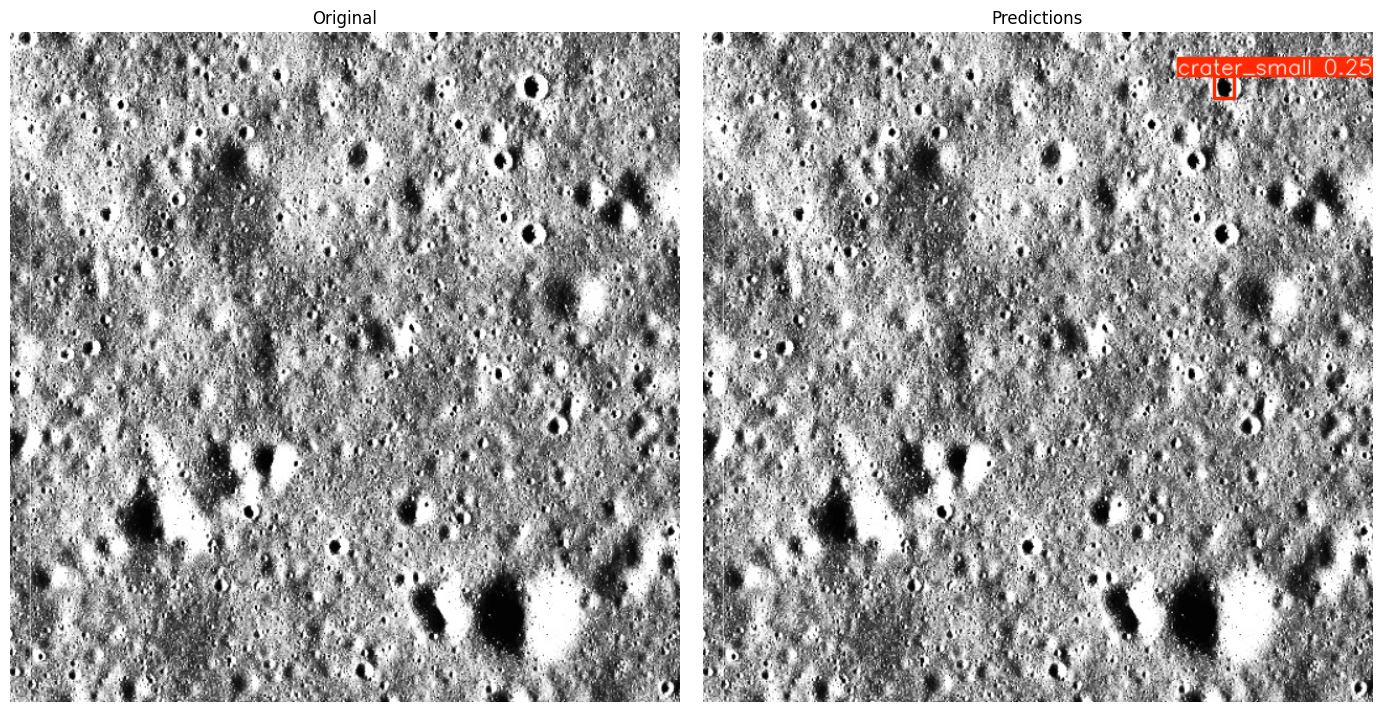

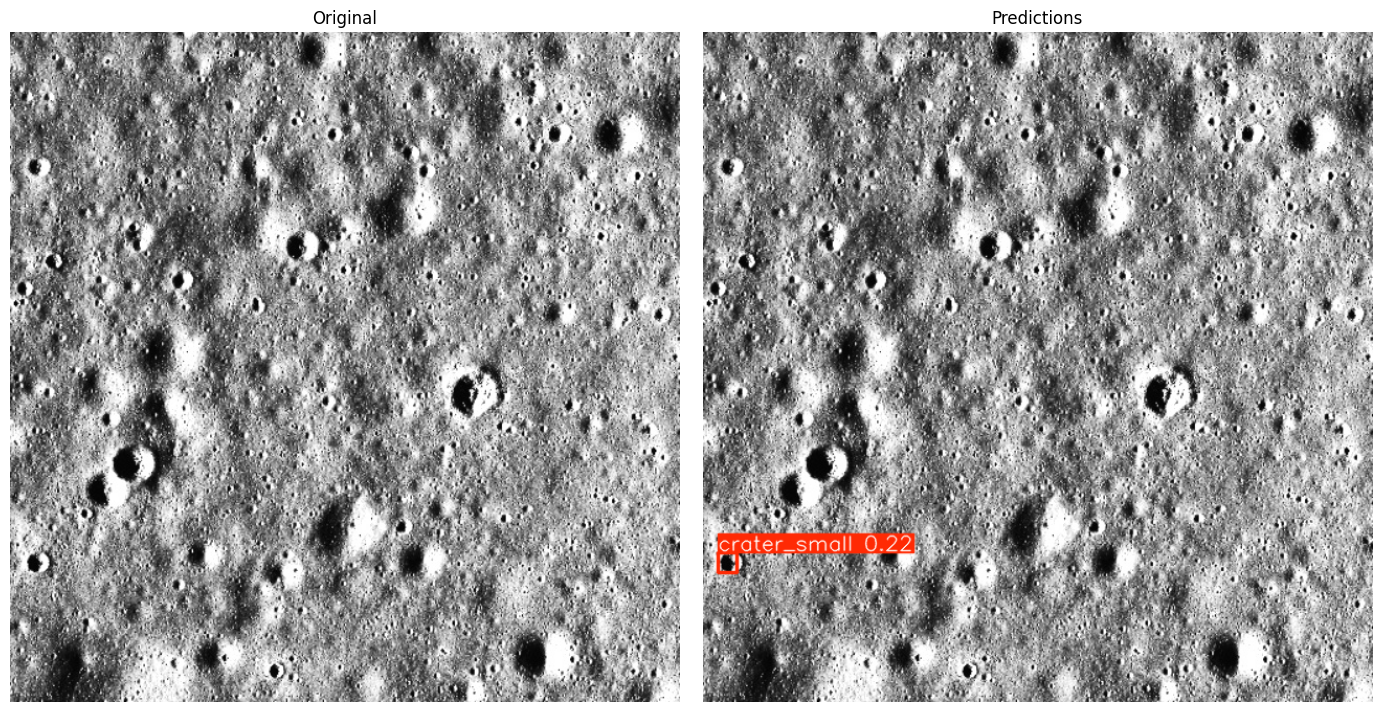

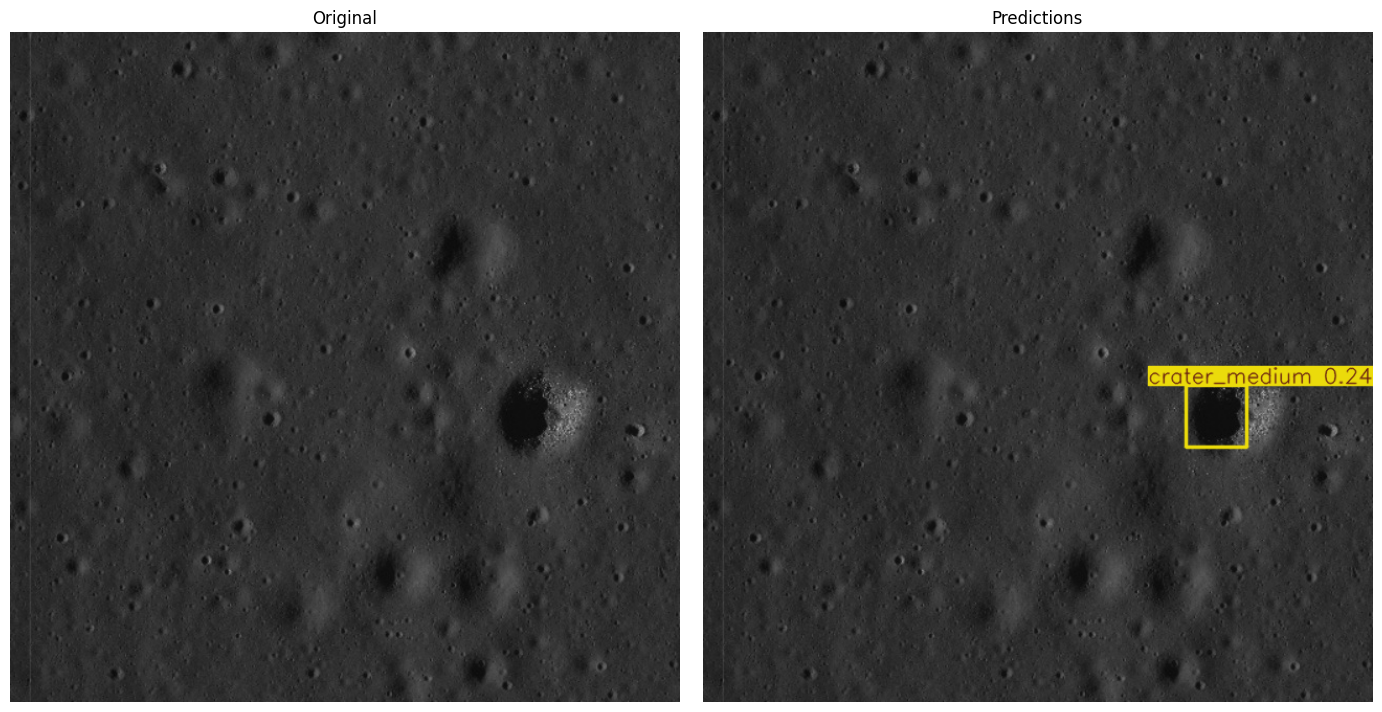

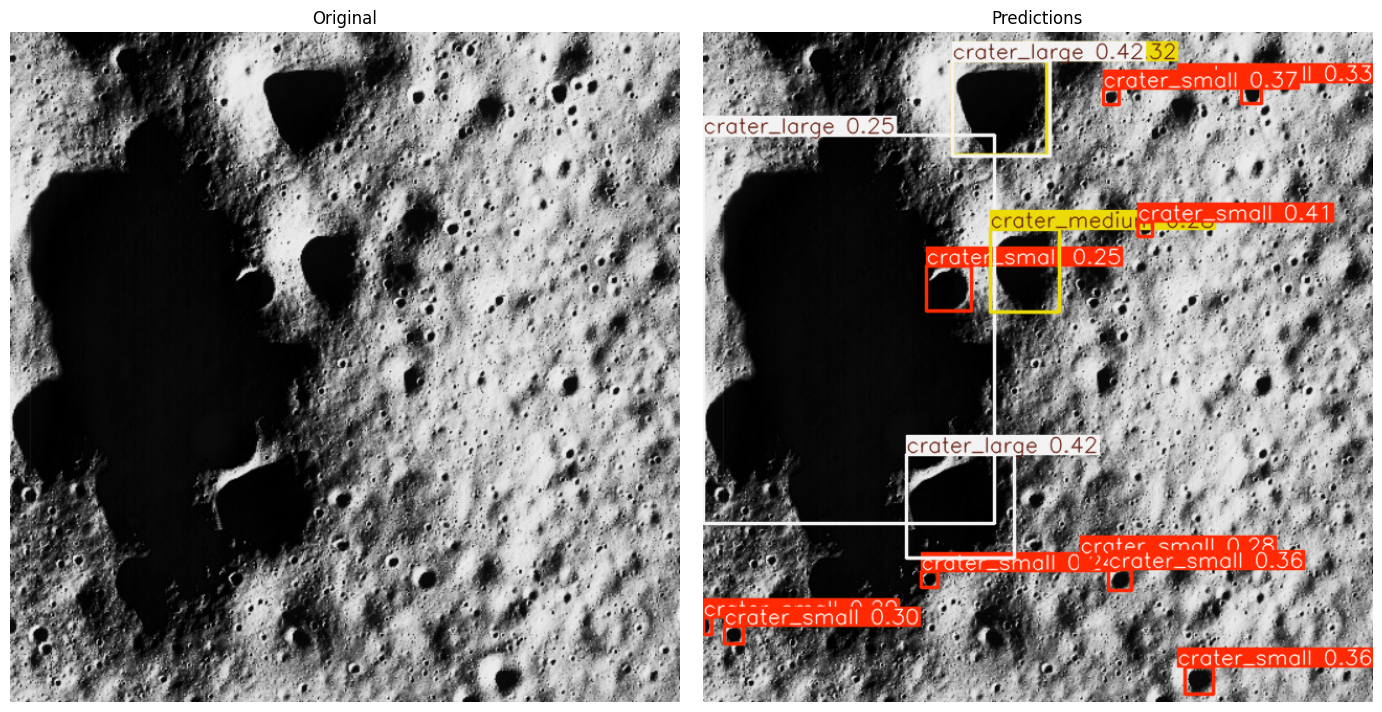

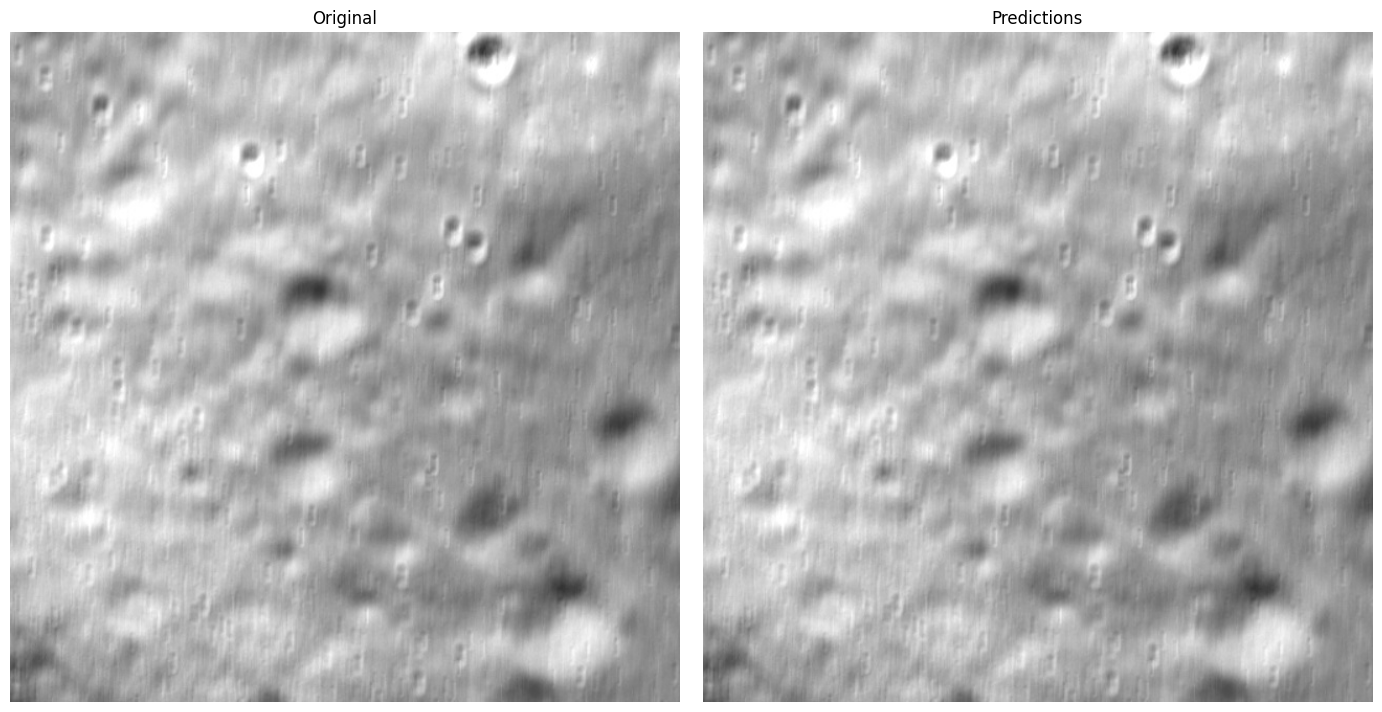

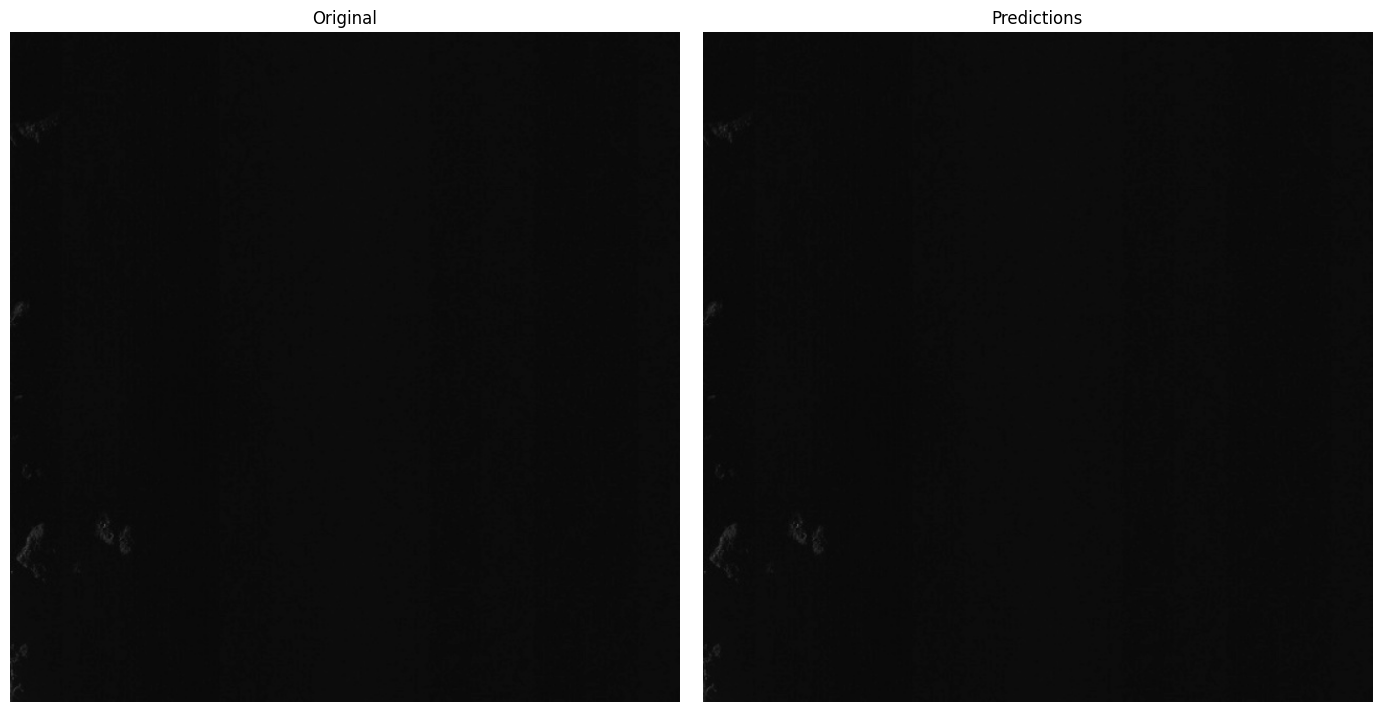

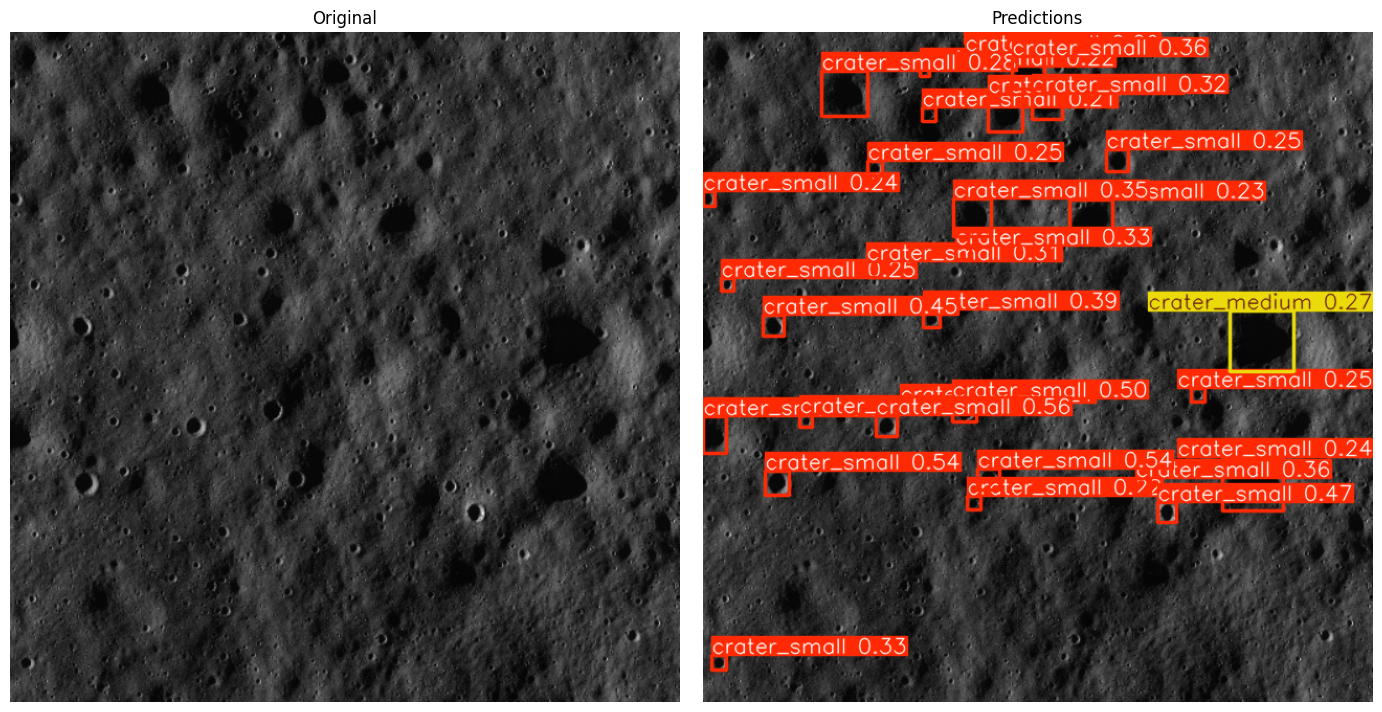

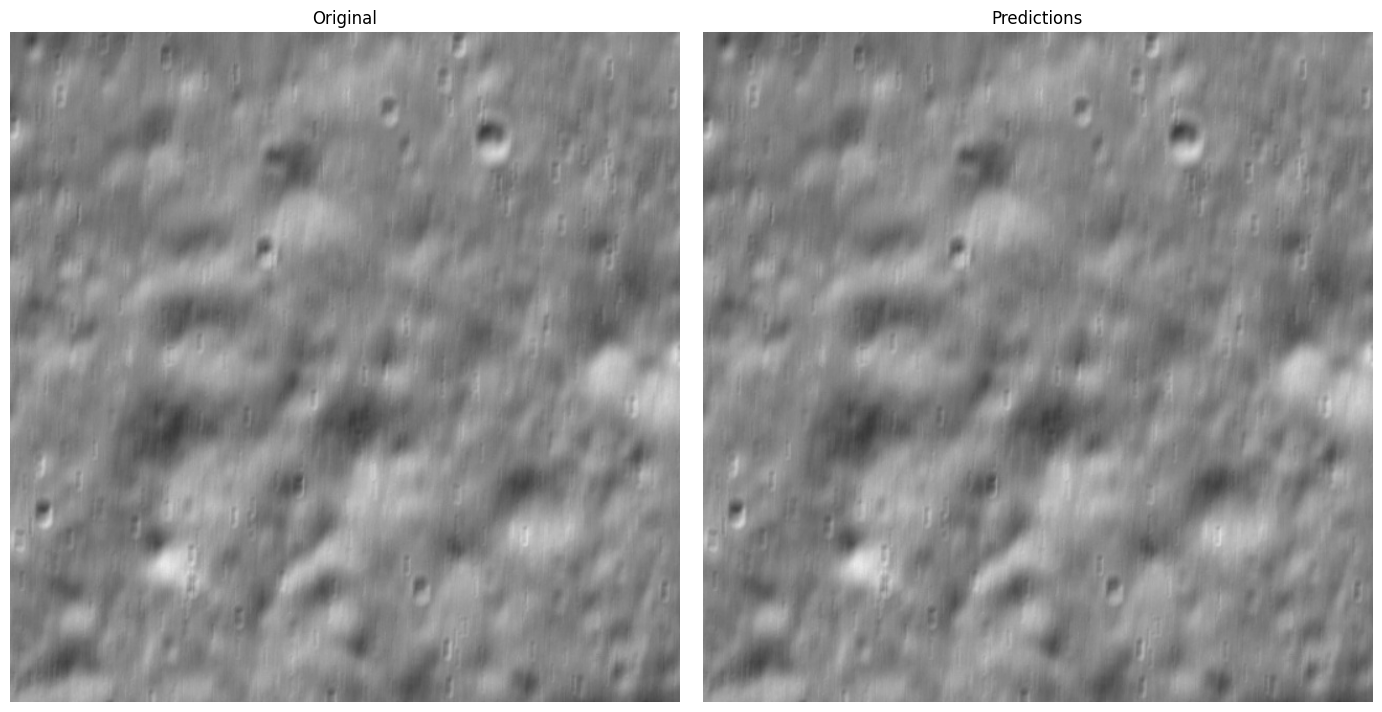

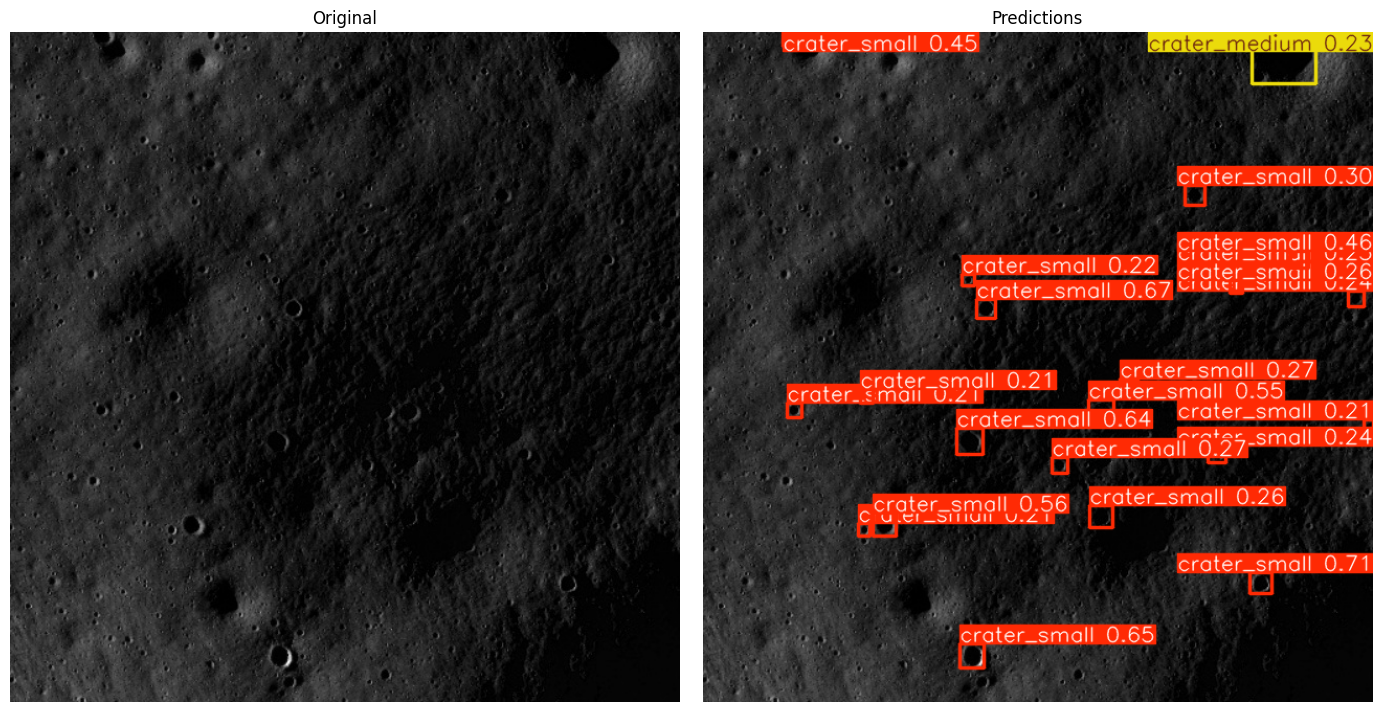

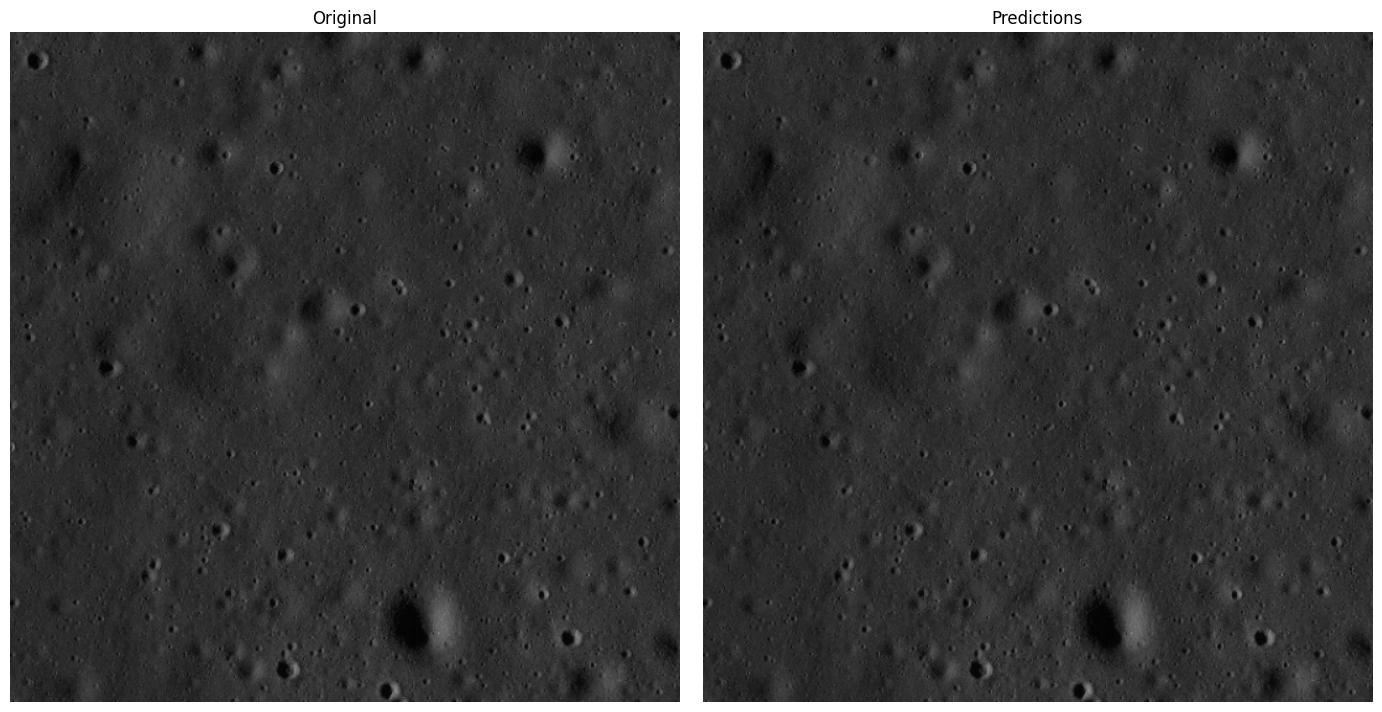

In [8]:
import os
import random
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# 🔹 Paths
image_folder = "/kaggle/input/datasets/dhriti1015/588images/tiles_remaining_650/tiles_remaining_650"
model_path = "/kaggle/input/models/dhriti1015/yolov11-final/other/default/1/best_v5_yolo11.pt"

# 🔹 Load model
model = YOLO(model_path)

# 🔹 Get image list
all_images = [f for f in os.listdir(image_folder)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# 🔹 Random 10 images
#random.seed(42)
selected_images = random.sample(all_images, 10)

# 🔹 Full paths
image_paths = [os.path.join(image_folder, img) for img in selected_images]

# 🔹 Run inference
results = model.predict(
    source=image_paths,
    conf=0.2,
    iou=0.45
)

# 🔥 SIDE-BY-SIDE DISPLAY
for img_path, r in zip(image_paths, results):
    
    # Original image
    orig = cv2.imread(img_path)
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    
    # Predicted image
    pred = r.plot()  # boxes + labels
    
    # Plot side by side
    fig, axs = plt.subplots(1, 2, figsize=(14, 7))
    
    axs[0].imshow(orig)
    axs[0].set_title("Original")
    axs[0].axis('off')
    
    axs[1].imshow(pred)
    axs[1].set_title("Predictions")
    axs[1].axis('off')
    
    plt.tight_layout()
    plt.show()